# Rasch Model (1PL)

We will mainly use the method of Bayesian Inference with Stan

## 1. Model Description

The **Rasch model** (also called the **one-parameter logistic model, 1PL**) is the most parsimonious IRT model for dichotomously scored items (0 = incorrect, 1 = correct).

### Response Probability

$$P(X_{ji} = 1 \mid \theta_j, b_i) = \frac{\exp(\theta_j - b_i)}{1 + \exp(\theta_j - b_i)} = \text{logistic}(\theta_j - b_i)$$

| Parameter | Name | Interpretation |
|-----------|------|----------------|
| $\theta_j$ | Person ability | Latent trait of person $j$ |
| $b_i$ | Item difficulty | Value of $\theta$ where $P = 0.5$ |

### Key Properties
- **Equal discrimination**: All items have slope = 1 on the logit scale (no $a_i$ parameter).
- **Sufficient statistics**: The raw sum score $\sum_i X_{ji}$ is a sufficient statistic for $\theta_j$.
- **Specific objectivity**: Item comparisons do not depend on the ability distribution.

### Estimation/Computation
- MLE/CML
- MAP
- Full posterior density estimation by MCMC

### Model Identification
- Centering the mean of items for MLE
- Not necessary for CML

In [1]:
# Purpose: set up plotting style, fonts, and core dependencies for the notebook.
# Purpose: initialize reproducible randomness and load CmdStanPy directly.
import sys as _sys, os as _os
import matplotlib as _mpl, matplotlib.font_manager as _fm

def _setup_korean_font():
    """Windows / macOS / Linux 에서 한국어 폰트를 자동 감지하여 등록."""
    _candidates = {
        'win32': [
            ('C:/Windows/Fonts/malgun.ttf',  'Malgun Gothic'),
            ('C:/Windows/Fonts/gulim.ttc',   'Gulim'),
            ('C:/Windows/Fonts/batang.ttc',  'Batang'),
        ],
        'darwin': [
            ('/System/Library/Fonts/AppleSDGothicNeo.ttc',               'Apple SD Gothic Neo'),
            ('/Library/Fonts/NanumGothic.ttf',                           'NanumGothic'),
            ('/usr/share/fonts/truetype/nanum/NanumGothic.ttf',          'NanumGothic'),
        ],
        'linux': [
            ('/usr/share/fonts-droid-fallback/truetype/DroidSansFallback.ttf', 'Droid Sans Fallback'),
            ('/usr/share/fonts/truetype/nanum/NanumGothic.ttf',                'NanumGothic'),
            ('/usr/share/fonts/truetype/droid/DroidSansFallback.ttf',          'Droid Sans Fallback'),
        ],
    }
    # 깨진 Full 변종 제거 (Linux 한정 이슈)
    _fm.fontManager.ttflist = [f for f in _fm.fontManager.ttflist
                                if not (f.name == 'Droid Sans Fallback' and 'Full' in f.fname)]
    platform = _sys.platform
    paths = _candidates.get(platform, _candidates['linux'])
    for path, name in paths:
        if _os.path.exists(path):
            _fm.fontManager.addfont(path)
            _mpl.rcParams['font.family'] = ['DejaVu Sans', name]
            return
    # 한국어 폰트 없으면 기본값 유지 (깨짐 경고 없이 fallback)
    _mpl.rcParams['font.family'] = 'DejaVu Sans'

_setup_korean_font()
_mpl.rcParams['axes.unicode_minus'] = False
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os, tempfile, warnings
import cmdstanpy
warnings.filterwarnings('ignore')

## 2. Synthetic Data Generation

We simulate responses from **N students** on **K items**.

- True person abilities: $\theta_j \sim \mathcal{N}(0, 1)$
- True item difficulties: $b_i \sim \mathcal{N}(0, 1)$ (centered)
- Responses: $Y_{ji} \sim \text{Bernoulli}(\text{logistic}(\theta_j - b_i))$

In [2]:
# Purpose: generate synthetic Rasch-response data from known true parameters.
# Purpose: create person abilities, item difficulties, and binary item responses.
NJ, NI = 200, 25  # persons, items

np.random.seed(5101) # reproducibility 위해 시드 고정 (5101로 설정)

theta_true = np.random.normal(0, 1, NJ)
b_true = np.random.normal(0, 1, NI)
b_true -= b_true.mean()  # center for identifiability

logit_p = theta_true[:, None] - b_true[None, :]
p_true = 1.0 / (1.0 + np.exp(-logit_p))
Y = (np.random.uniform(size=(NJ, NI)) < p_true).astype(int)

print(f"Response matrix shape : {Y.shape}")
print(f"Overall p(correct)    : {Y.mean():.3f}")
print(f"Person score range    : {Y.sum(axis=1).min()} – {Y.sum(axis=1).max()}")
print(f"Item difficulty range : [{b_true.min():.2f}, {b_true.max():.2f}]")

Response matrix shape : (200, 25)
Overall p(correct)    : 0.476
Person score range    : 2 – 23
Item difficulty range : [-1.34, 1.74]


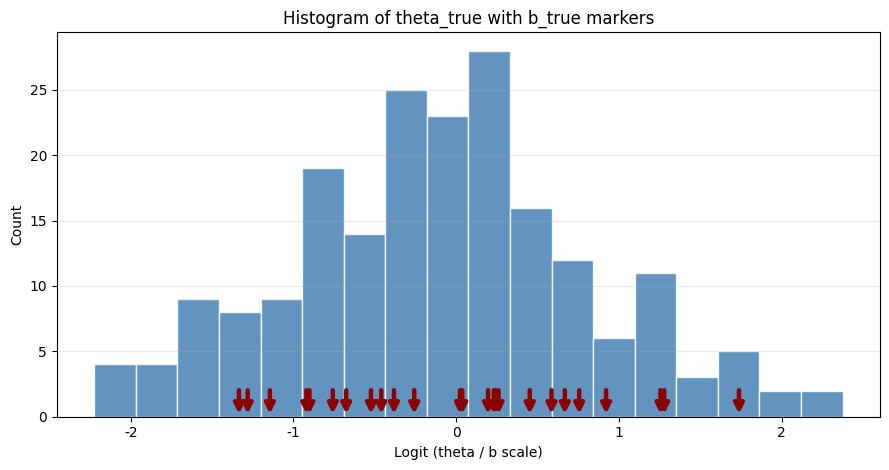

In [3]:
# Histogram of true person abilities (theta) on the logit scale
fig, ax = plt.subplots(figsize=(9, 4.8))

counts, bins, _ = ax.hist(
    theta_true,
    bins=18,
    color='steelblue',
    edgecolor='white',
    alpha=0.85
)

# Short, thick arrows marking true item difficulties (b) on the same logit axis
ymax = max(counts) if len(counts) else 1.0
arrow_base = 0.0
arrow_len = max(0.08 * ymax, 0.6)

for b in np.ravel(b_true):
    ax.annotate(
        '',
        xy=(b, arrow_base),
        xytext=(b, arrow_base + arrow_len),
        arrowprops=dict(arrowstyle='-|>', lw=3.2, color='darkred', mutation_scale=14)
    )

ax.set_xlabel('Logit (theta / b scale)')
ax.set_ylabel('Count')
ax.set_title('Histogram of theta_true with b_true markers')
ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

#### Y: Response Matrix


In [4]:
import pandas as pd
df_Y = pd.DataFrame(Y, columns=[f'Item_{i+1}' for i in range(NI)])
df_Y['Person_ID'] = [f'Person_{j+1}' for j in range(NJ)]
df_Y = df_Y.set_index('Person_ID')
df_Y.head()

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,...,Item_16,Item_17,Item_18,Item_19,Item_20,Item_21,Item_22,Item_23,Item_24,Item_25
Person_ID,,,,,,,,,,,,,,,,,,,,,
Person_1,1,0,1,0,0,1,1,0,0,1,...,1,1,0,0,1,0,0,0,0,1
Person_2,1,1,1,0,0,1,1,0,0,1,...,0,1,0,0,0,1,0,1,0,1
Person_3,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
Person_4,0,1,0,1,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
Person_5,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0


---
### DIY: Do inspect the response matrix $Y$

데이터프레임 df_Y 를 사용하여 응답 결과에 대한 관찰 해석(Exploratory Data Analysis (EDA)) 하시오.
- Compute `total score`
- Compute `proportion correct`
- Draw histograms
- Draw Scalogram (Guttmann Structure)

In [5]:
# EDA Code must come here. Inspect the response matrix `Y`:

---

## 3.A MLE Estimation

The MLE parameters are computed.

In [6]:
# Purpose: define the Rasch model in Stan and compile it for MLE estimation.
# Data Format: long format with columns: person_id, item_id, response (0/1)
stan_code_mle = """
data {
    int<lower=1> J;                        // number of persons
    int<lower=1> I;                        // number of items
    int<lower=0> N;                        // total observations
    array[N] int<lower=1,upper=J> jj;      // person indicator
    array[N] int<lower=1,upper=I> ii;      // item indicator
    array[N] int<lower=0,upper=1> y;       // binary responses
}
parameters {
    vector[J] theta;                       // person abilities
    vector[I-1] b_free;                    // Free item difficulties (I-1); 
                                           // the last one, b_free[I], is determined by sum-to-zero constraint
}
transformed parameters {
    vector[I] b;
    b[1:I-1] = b_free;
    b[I] = -sum(b_free);                  // sum-to-zero constraint: mean(b) = 0 for identifiability
}
model {
    // No ability prior (identifies scale)
    // No difficulty prior
    for (n in 1:N)
        y[n] ~ bernoulli_logit(theta[jj[n]] - b[ii[n]]);
}
"""

# Write the code to a .stan file for CmdStanPy
stan_file_mle = 'rasch_1pl_mle.stan'
with open(stan_file_mle, 'w') as f:
    f.write(stan_code_mle)

# Compile the model
model_mle = cmdstanpy.CmdStanModel(stan_file=stan_file_mle)

23:26:20 - cmdstanpy - INFO - compiling stan file C:\Users\yongd\Downloads\KOS-5101\irt\rasch_1pl_mle.stan to exe file C:\Users\yongd\Downloads\KOS-5101\irt\rasch_1pl_mle.exe
23:26:30 - cmdstanpy - INFO - compiled model executable: C:\Users\yongd\Downloads\KOS-5101\irt\rasch_1pl_mle.exe


In [7]:
# Prepare long-format data
jj_arr, ii_arr, y_arr = [], [], []
for j in range(NJ):
    for i in range(NI):
        jj_arr.append(j + 1)
        ii_arr.append(i + 1)
        y_arr.append(int(Y[j, i]))

# Data dictionary for Stan (MLE estimation)
stan_data = {'J': NJ, 'I': NI, 'N': NJ * NI,
             'jj': jj_arr, 'ii': ii_arr, 'y': y_arr}

# Run optimization for MLE
fit_mle = model_mle.optimize(data=stan_data)


23:26:30 - cmdstanpy - INFO - Chain [1] start processing
23:26:30 - cmdstanpy - INFO - Chain [1] done processing


In [8]:
b_mle = fit_mle.stan_variable('b')
theta_mle = fit_mle.stan_variable('theta')

print("Estimated item difficulties (b):", b_mle[:5])  # Show first 5 for brevity
print("Estimated person abilities (theta):", theta_mle[:5])  # Show first 5 for brevity

Estimated item difficulties (b): [ 0.1372172  -1.4969013  -0.03446408  0.72740938  1.4254274 ]
Estimated person abilities (theta): [ 0.0935644  -0.09554609 -2.2648665  -0.88619109 -1.1055479 ]


## Confidence Intervals for Rasch MLE Parameters

### Log-likelihood

$\ell(\boldsymbol{\theta}, \mathbf{b}) = \sum_{j,i} \Bigl[ x_{ji}(\theta_j - b_i) - \log\bigl(1 + e^{\theta_j - b_i}\bigr) \Bigr]$

### Fisher Information

Let $\hat{P}_{ji} = \text{logistic}(\hat\theta_j - \hat b_i)$ be the model-predicted probability and

$\hat{W}_{ji} = \hat{P}_{ji}(1 - \hat{P}_{ji})$

the Bernoulli variance (Rasch weight) at the MLE. The **observed Fisher information** for each parameter is the diagonal of the negative Hessian of $\ell$:

| Parameter | Fisher information |
|---|---|
| $\hat\theta_j$ | $\mathcal{I}(\hat\theta_j) = \displaystyle\sum_i \hat{W}_{ji}$ |
| $\hat b_i$ | $\mathcal{I}(\hat b_i) = \displaystyle\sum_j \hat{W}_{ji}$ |

> Off-diagonal blocks between $\theta_j$ and $b_i$ are zero in the **CML** case; they are non-zero in **JML**, where the full $(J+I)\times(J+I)$ Hessian must be inverted.

### Standard Errors

$\text{SE}(\hat\theta_j) = \frac{1}{\sqrt{\displaystyle\sum_i \hat{W}_{ji}}}, \qquad \text{SE}(\hat b_i) = \frac{1}{\sqrt{\displaystyle\sum_j \hat{W}_{ji}}}$

### Asymptotic $(1-\alpha)$ Confidence Intervals

$\hat\theta_j \pm z_{\alpha/2}\,\text{SE}(\hat\theta_j), \qquad \hat b_i \pm z_{\alpha/2}\,\text{SE}(\hat b_i)$

For 95% CIs, $z_{0.025} = 1.96$.

### Remarks

- **JML**: estimate all $\theta_j$ and $b_i$ simultaneously; $\text{SE} = \sqrt{\operatorname{diag}(\mathcal{I}^{-1})}$ from the full Hessian.
- **CML** (Rasch preferred): condition on raw scores to eliminate $\theta$ nuisance parameters, estimate $\hat{\mathbf{b}}$ from the conditional likelihood, then estimate each $\hat\theta_j$ given $\hat{\mathbf{b}}$; the same SE formula applies in each stage.
- CIs are asymptotically valid only; for extreme scores (all-correct or all-wrong) the MLE is $\pm\infty$ and the CI is undefined.

In [9]:
# Confidence intervals for MLE person (theta) and item (b) parameters
# Formula:  SE(theta_j) = 1 / sqrt(sum_i W_ji),  SE(b_i) = 1 / sqrt(sum_j W_ji)
# where W_ji = P_ji * (1 - P_ji),  P_ji = logistic(theta_j - b_i)
import numpy as np
import pandas as pd

z = 1.96  # 95% CI

# Predicted probabilities and Rasch weights at the MLE
eta = theta_mle[:, None] - b_mle[None, :]          # (NJ, NI)
P_hat = 1.0 / (1.0 + np.exp(-eta))                 # logistic
W_hat = P_hat * (1.0 - P_hat)                      # Bernoulli variance

# Standard errors
SE_theta = 1.0 / np.sqrt(W_hat.sum(axis=1))        # (NJ,)
SE_b     = 1.0 / np.sqrt(W_hat.sum(axis=0))        # (NI,)

# 95% confidence intervals
theta_lo, theta_hi = theta_mle - z * SE_theta, theta_mle + z * SE_theta
b_lo,     b_hi     = b_mle     - z * SE_b,     b_mle     + z * SE_b

# ── Person parameters ─────────────────────────────────────────────────────────
df_theta = pd.DataFrame({
    'Person j':   np.arange(1, len(theta_mle) + 1),
    'theta_MLE':  theta_mle,
    'SE':         SE_theta,
    'CI_low':     theta_lo,
    'CI_high':    theta_hi,
    'theta_true': theta_true,
})
print('=== Person Parameters (theta) — first 10 rows ===')
print(df_theta.head(10).to_string(index=False, float_format=lambda x: f'{x:8.4f}'))
print()

# ── Item parameters ───────────────────────────────────────────────────────────
df_b = pd.DataFrame({
    'Item i':  np.arange(1, len(b_mle) + 1),
    'b_MLE':   b_mle,
    'SE':      SE_b,
    'CI_low':  b_lo,
    'CI_high': b_hi,
    'b_true':  b_true,
})
print('=== Item Parameters (b) ===')
print(df_b.to_string(index=False, float_format=lambda x: f'{x:8.4f}'))
print()
print(f'Coverage check (theta): true value inside 95% CI for {(  (theta_true >= theta_lo) & (theta_true <= theta_hi)).mean()*100:.1f}% of persons')
print(f'Coverage check (b):     true value inside 95% CI for {((b_true     >= b_lo)     & (b_true     <= b_hi)).mean()*100:.1f}% of items')

=== Person Parameters (theta) — first 10 rows ===
 Person j  theta_MLE       SE   CI_low  CI_high  theta_true
        1     0.0936   0.4354  -0.7599   0.9470      0.4976
        2    -0.0955   0.4354  -0.9490   0.7579      0.3101
        3    -2.2649   0.6371  -3.5136  -1.0161     -1.5268
        4    -0.8862   0.4612  -1.7901   0.0177     -0.7899
        5    -1.1055   0.4765  -2.0394  -0.1717     -0.2339
        6    -0.4797   0.4426  -1.3472   0.3877     -0.4100
        7    -0.2859   0.4378  -1.1439   0.5721     -0.1512
        8     0.0936   0.4354  -0.7599   0.9471      0.0335
        9     1.1045   0.4768   0.1699   2.0390      1.1196
       10    -0.0957   0.4354  -0.9492   0.7577     -0.7082

=== Item Parameters (b) ===
 Item i    b_MLE       SE   CI_low  CI_high   b_true
      1   0.1372   0.1570  -0.1705   0.4450   0.0233
      2  -1.4969   0.1795  -1.8487  -1.1451  -1.3350
      3  -0.0345   0.1563  -0.3409   0.2719   0.2602
      4   0.7274   0.1649   0.4041   1.0507   0.4

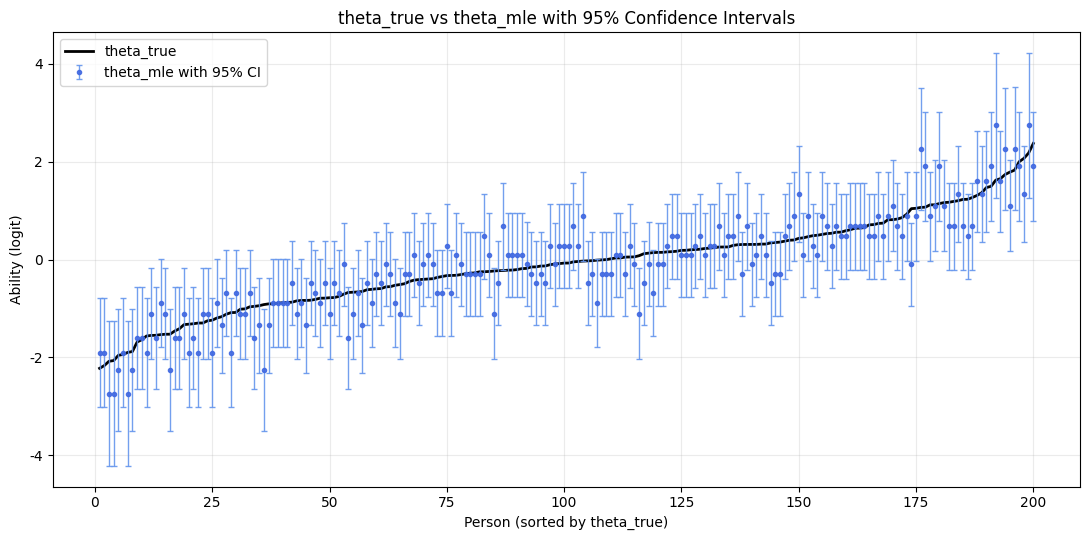

In [10]:
# Plot theta_true and theta_mle together with 95% CI for theta_mle
import numpy as np
import matplotlib.pyplot as plt

# Recompute CI pieces if this cell is run independently
if 'theta_lo' not in globals() or 'theta_hi' not in globals():
    z = 1.96
    eta = theta_mle[:, None] - b_mle[None, :]
    P_hat = 1.0 / (1.0 + np.exp(-eta))
    W_hat = P_hat * (1.0 - P_hat)
    SE_theta = 1.0 / np.sqrt(W_hat.sum(axis=1))
    theta_lo = theta_mle - z * SE_theta
    theta_hi = theta_mle + z * SE_theta

# Sort persons by true ability for a cleaner comparison plot
order = np.argsort(theta_true)
x = np.arange(1, len(theta_true) + 1)

theta_true_sorted = theta_true[order]
theta_mle_sorted = theta_mle[order]
theta_lo_sorted = theta_lo[order]
theta_hi_sorted = theta_hi[order]
yerr = np.vstack([theta_mle_sorted - theta_lo_sorted, theta_hi_sorted - theta_mle_sorted])

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(x, theta_true_sorted, color='black', lw=2.0, label='theta_true')
ax.errorbar(
    x,
    theta_mle_sorted,
    yerr=yerr,
    fmt='o',
    ms=3,
    color='royalblue',
    ecolor='cornflowerblue',
    elinewidth=1.0,
    capsize=2,
    alpha=0.9,
    label='theta_mle with 95% CI'
)

ax.set_xlabel('Person (sorted by theta_true)')
ax.set_ylabel('Ability (logit)')
ax.set_title('theta_true vs theta_mle with 95% Confidence Intervals')
ax.grid(alpha=0.25)
ax.legend(loc='best')

plt.tight_layout()
plt.show()

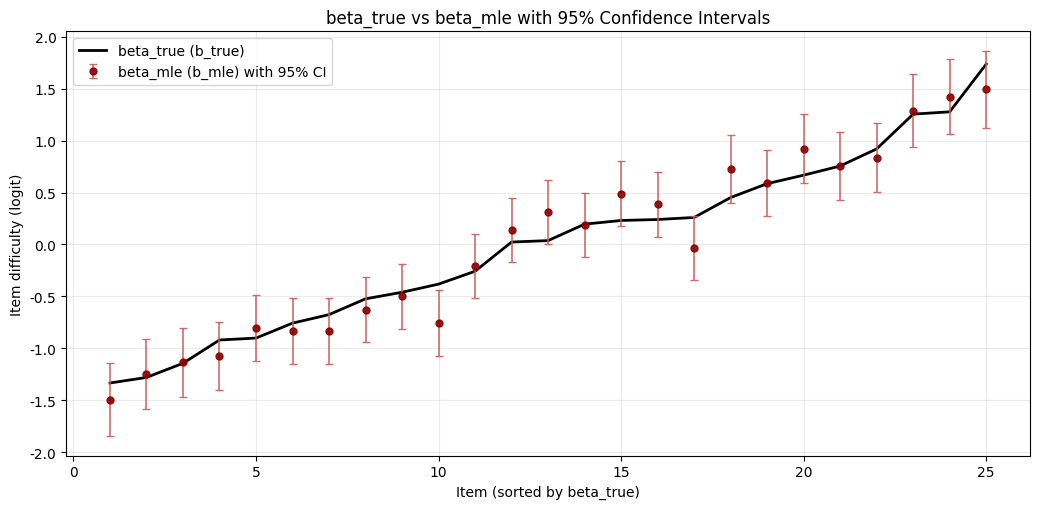

In [11]:
# Plot beta_true and beta_mle together with 95% CI for beta_mle
# (Using Rasch notation in this notebook: beta == b)
import numpy as np
import matplotlib.pyplot as plt

# Recompute CI pieces for b if this cell is run independently
if 'b_lo' not in globals() or 'b_hi' not in globals():
    z = 1.96
    eta = theta_mle[:, None] - b_mle[None, :]
    P_hat = 1.0 / (1.0 + np.exp(-eta))
    W_hat = P_hat * (1.0 - P_hat)
    SE_b = 1.0 / np.sqrt(W_hat.sum(axis=0))
    b_lo = b_mle - z * SE_b
    b_hi = b_mle + z * SE_b

# Sort items by true beta (b_true) for readability
order_b = np.argsort(b_true)
x_b = np.arange(1, len(b_true) + 1)

beta_true_sorted = b_true[order_b]
beta_mle_sorted = b_mle[order_b]
beta_lo_sorted = b_lo[order_b]
beta_hi_sorted = b_hi[order_b]
yerr_b = np.vstack([beta_mle_sorted - beta_lo_sorted, beta_hi_sorted - beta_mle_sorted])

fig, ax = plt.subplots(figsize=(10.5, 5.2))
ax.plot(x_b, beta_true_sorted, color='black', lw=2.0, label='beta_true (b_true)')
ax.errorbar(
    x_b,
    beta_mle_sorted,
    yerr=yerr_b,
    fmt='o',
    ms=5,
    color='darkred',
    ecolor='indianred',
    elinewidth=1.2,
    capsize=3,
    alpha=0.9,
    label='beta_mle (b_mle) with 95% CI'
)

ax.set_xlabel('Item (sorted by beta_true)')
ax.set_ylabel('Item difficulty (logit)')
ax.set_title('beta_true vs beta_mle with 95% Confidence Intervals')
ax.grid(alpha=0.25)
ax.legend(loc='best')

plt.tight_layout()
plt.show()

## Does Stan `optimize()` Produce JML or CML?

In this notebook, Stan `optimize()` is acting like **JML (Joint Maximum Likelihood)**, not CML.

### Why this is JML

- In the Stan model, both person parameters $\theta_j$ and item parameters $b_i$ are declared in `parameters` and estimated together.
- `optimize()` maximizes the objective jointly over all free parameters.
- Therefore, the estimation is joint over persons and items, which is the JML role.

### Why this is not CML

- **CML (Conditional Maximum Likelihood)** for Rasch conditions on person raw scores to remove $\theta_j$ as nuisance parameters.
- Then only item parameters are estimated from the conditional likelihood.
- That conditioning step is not being done in this Stan model.

### Practical note

- If priors are included, `optimize()` returns a **MAP** estimate.
- In your current MLE setup (no priors, with sum-to-zero constraint on $b$), this is a constrained **JML-style MLE**.

CML (package: girth.rasch_conditional) results
corr(beta_mle, beta_cml)   = 1.0000
RMSE(beta_mle, beta_cml)   = 0.0376
corr(theta_mle, theta_cml) = 1.0000
RMSE(theta_mle, theta_cml) = 0.0112
Mean CML beta CI width     = 0.6115
Mean CML theta CI width    = 1.8588


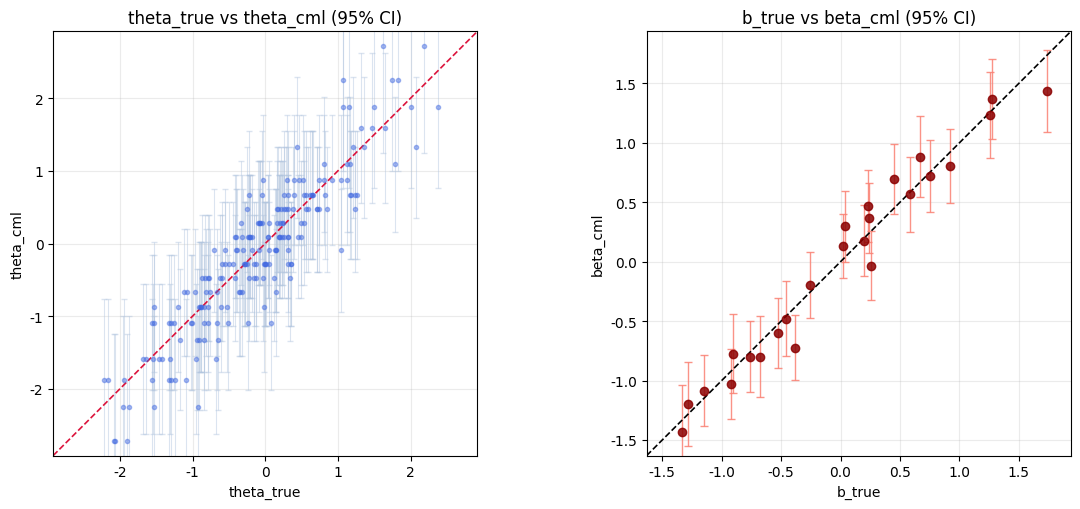

In [12]:
# CML using a ready-made package (girth) + performance comparison vs MLE
import numpy as np
import matplotlib.pyplot as plt
from girth import rasch_conditional, ability_mle

# girth expects data as [items x participants]
X = Y.T.astype(bool)

# ---- CML item estimation (package) ----
fit_cml_pkg = rasch_conditional(X)
if isinstance(fit_cml_pkg, dict):
    beta_cml = np.asarray(fit_cml_pkg['Difficulty'], dtype=float)
else:
    beta_cml = np.asarray(fit_cml_pkg, dtype=float)

# ---- Person ability estimation given CML items (package MLE) ----
a1 = np.ones_like(beta_cml)
theta_cml = np.asarray(ability_mle(X, beta_cml, a1), dtype=float)

# Fill any non-estimable abilities (if extreme patterns appear)
if np.isnan(theta_cml).any():
    theta_cml = np.where(np.isnan(theta_cml), np.nanmean(theta_cml), theta_cml)

# ---- CIs ----
# Item CIs: bootstrap over persons (robust and model-agnostic)
rng = np.random.default_rng(5101)
B = 200
beta_boot = np.zeros((B, NI), dtype=float)

for b in range(B):
    idx = rng.integers(0, NJ, NJ)
    Xb = Y[idx, :].T.astype(bool)
    fit_b = rasch_conditional(Xb)
    if isinstance(fit_b, dict):
        beta_boot[b] = np.asarray(fit_b['Difficulty'], dtype=float)
    else:
        beta_boot[b] = np.asarray(fit_b, dtype=float)

beta_cml_lo = np.percentile(beta_boot, 2.5, axis=0)
beta_cml_hi = np.percentile(beta_boot, 97.5, axis=0)
se_beta_cml = beta_boot.std(axis=0, ddof=1)

# Person CIs: info-based approximation at CML estimates
eta_cml = theta_cml[:, None] - beta_cml[None, :]
P_cml = 1.0 / (1.0 + np.exp(-eta_cml))
W_cml = P_cml * (1.0 - P_cml)
se_theta_cml = 1.0 / np.sqrt(np.clip(W_cml.sum(axis=1), 1e-10, None))

theta_cml_lo = theta_cml - 1.96 * se_theta_cml
theta_cml_hi = theta_cml + 1.96 * se_theta_cml

# ---- Performance comparison: CML vs MLE ----
corr_beta = np.corrcoef(b_mle, beta_cml)[0, 1]
rmse_beta = np.sqrt(np.mean((b_mle - beta_cml) ** 2))

corr_theta = np.corrcoef(theta_mle, theta_cml)[0, 1]
rmse_theta = np.sqrt(np.mean((theta_mle - theta_cml) ** 2))

print('CML (package: girth.rasch_conditional) results')
print(f'corr(beta_mle, beta_cml)   = {corr_beta:.4f}')
print(f'RMSE(beta_mle, beta_cml)   = {rmse_beta:.4f}')
print(f'corr(theta_mle, theta_cml) = {corr_theta:.4f}')
print(f'RMSE(theta_mle, theta_cml) = {rmse_theta:.4f}')
print(f'Mean CML beta CI width     = {(beta_cml_hi - beta_cml_lo).mean():.4f}')
print(f'Mean CML theta CI width    = {(theta_cml_hi - theta_cml_lo).mean():.4f}')

# ---- Visual checks against true parameters with CIs ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))

# theta_true vs theta_cml
axes[0].errorbar(
    theta_true,
    theta_cml,
    yerr=1.96 * se_theta_cml,
    fmt='o',
    ms=3,
    alpha=0.45,
    color='royalblue',
    ecolor='lightsteelblue',
    elinewidth=0.8,
    capsize=2,
)
lo = min(theta_true.min(), theta_cml.min()) - 0.2
hi = max(theta_true.max(), theta_cml.max()) + 0.2
axes[0].plot([lo, hi], [lo, hi], '--', color='crimson', lw=1.2)
axes[0].set_xlim(lo, hi)
axes[0].set_ylim(lo, hi)
axes[0].set_aspect('equal', adjustable='box')
axes[0].set_title('theta_true vs theta_cml (95% CI)')
axes[0].set_xlabel('theta_true')
axes[0].set_ylabel('theta_cml')
axes[0].grid(alpha=0.25)

# b_true vs beta_cml
axes[1].errorbar(
    b_true,
    beta_cml,
    yerr=1.96 * se_beta_cml,
    fmt='o',
    ms=6,
    alpha=0.85,
    color='darkred',
    ecolor='salmon',
    elinewidth=1.0,
    capsize=3,
)
lo = min(b_true.min(), beta_cml.min()) - 0.2
hi = max(b_true.max(), beta_cml.max()) + 0.2
axes[1].plot([lo, hi], [lo, hi], '--', color='black', lw=1.2)
axes[1].set_xlim(lo, hi)
axes[1].set_ylim(lo, hi)
axes[1].set_aspect('equal', adjustable='box')
axes[1].set_title('b_true vs beta_cml (95% CI)')
axes[1].set_xlabel('b_true')
axes[1].set_ylabel('beta_cml')
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

## JML vs CML: Which Should Be Used in Practice?

### Core Difference

- **JML (Joint Maximum Likelihood)** estimates all person and item parameters together.
- **CML (Conditional Maximum Likelihood)** conditions on person raw scores, removes person nuisance parameters, and estimates item parameters first.

### Practical Comparison

- **Bias / consistency**:
  - JML item estimates can have finite-sample bias (incidental-parameter problem), especially with short tests.
  - CML item estimates are generally better behaved for Rasch measurement and are consistent under standard Rasch assumptions.
- **Extreme scores**:
  - JML and person-level MLE both struggle with all-correct/all-wrong respondents.
  - CML avoids this problem for item calibration because item estimation conditions out person parameters.
- **Rasch invariance**:
  - CML aligns closely with Rasch's specific objectivity principle.
  - JML can be useful operationally, but is less faithful to Rasch's classical conditional framework.
- **Computation**:
  - JML can be straightforward in generic optimizers (like Stan `optimize()`).
  - CML needs a dedicated conditional-likelihood implementation but is standard in Rasch software.

### Recommendation

For **Rasch 1PL item calibration**, use **CML** in practice when available.

- It is usually preferred for item parameter estimation quality and Rasch-specific inferential validity.
- After obtaining item estimates by CML, estimate person abilities in a second step (MLE/WLE/EAP) depending on your reporting goal.
- Use JML mainly when you need a quick joint baseline or when CML tooling is unavailable, and interpret item estimates more cautiously.

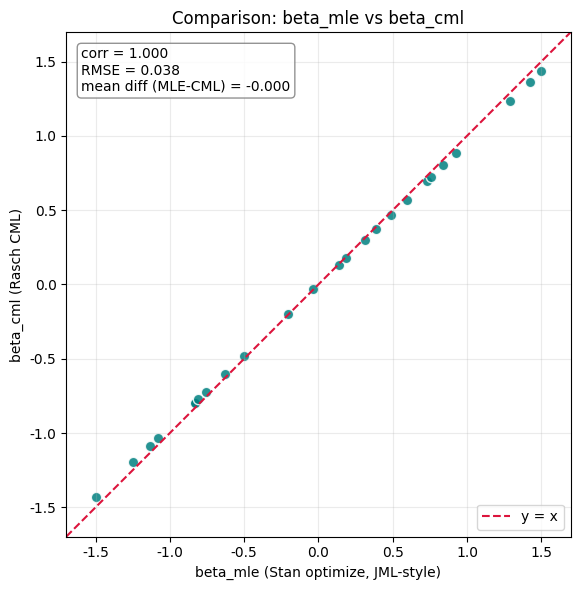

Correlation(beta_mle, beta_cml): 1.0000
RMSE(beta_mle, beta_cml): 0.0376
Mean difference (beta_mle - beta_cml): -0.0000


In [13]:
# Compare beta_mle and beta_cml
import numpy as np
import matplotlib.pyplot as plt

if 'beta_cml' not in globals():
    raise ValueError("beta_cml not found. Run the CML cell first.")

if len(b_mle) != len(beta_cml):
    raise ValueError("Length mismatch between b_mle and beta_cml.")

corr = np.corrcoef(b_mle, beta_cml)[0, 1]
rmse = np.sqrt(np.mean((b_mle - beta_cml) ** 2))
mean_diff = np.mean(b_mle - beta_cml)

fig, ax = plt.subplots(figsize=(6.4, 6.0))
ax.scatter(b_mle, beta_cml, s=55, alpha=0.85, color='teal', edgecolor='white')

lo = min(b_mle.min(), beta_cml.min()) - 0.2
hi = max(b_mle.max(), beta_cml.max()) + 0.2
ax.plot([lo, hi], [lo, hi], '--', color='crimson', lw=1.5, label='y = x')

ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('beta_mle (Stan optimize, JML-style)')
ax.set_ylabel('beta_cml (Rasch CML)')
ax.set_title('Comparison: beta_mle vs beta_cml')
ax.grid(alpha=0.25)
ax.legend(loc='best')

text = f"corr = {corr:.3f}\nRMSE = {rmse:.3f}\nmean diff (MLE-CML) = {mean_diff:.3f}"
ax.text(0.03, 0.97, text, transform=ax.transAxes, va='top', ha='left',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='gray'))

plt.tight_layout()
plt.show()

print(f"Correlation(beta_mle, beta_cml): {corr:.4f}")
print(f"RMSE(beta_mle, beta_cml): {rmse:.4f}")
print(f"Mean difference (beta_mle - beta_cml): {mean_diff:.4f}")

Why are beta_mle and beta_cml almost the same?
1) This is a pure Rasch (1PL) simulation generated from the same model form used for estimation.
2) The sample size is fairly large (many persons), so JML and CML tend to converge to very similar item estimates.
3) Identifiability constraints are aligned (item-location centered), reducing scale/shift differences.
4) In well-behaved Rasch data, practical differences between JML and CML item locations are often small.

corr(beta_mle, beta_cml) = 1.000000
RMSE(beta_mle, beta_cml) = 0.037571
max |beta_mle - beta_cml| = 0.065560

Item-level CI comparison (first 10 rows):
 Item  beta_mle  MLE_CI_low  MLE_CI_high  MLE_CI_width  beta_cml  CML_CI_low  CML_CI_high  CML_CI_width  CI_overlap  width_diff(CML-MLE)
    1    0.1372     -0.1705       0.4450        0.6155    0.1308     -0.1463       0.4110        0.5574      0.5574              -0.0581
    2   -1.4969     -1.8487      -1.1451        0.7035   -1.4313     -1.8580      -1.1015        0.7565   

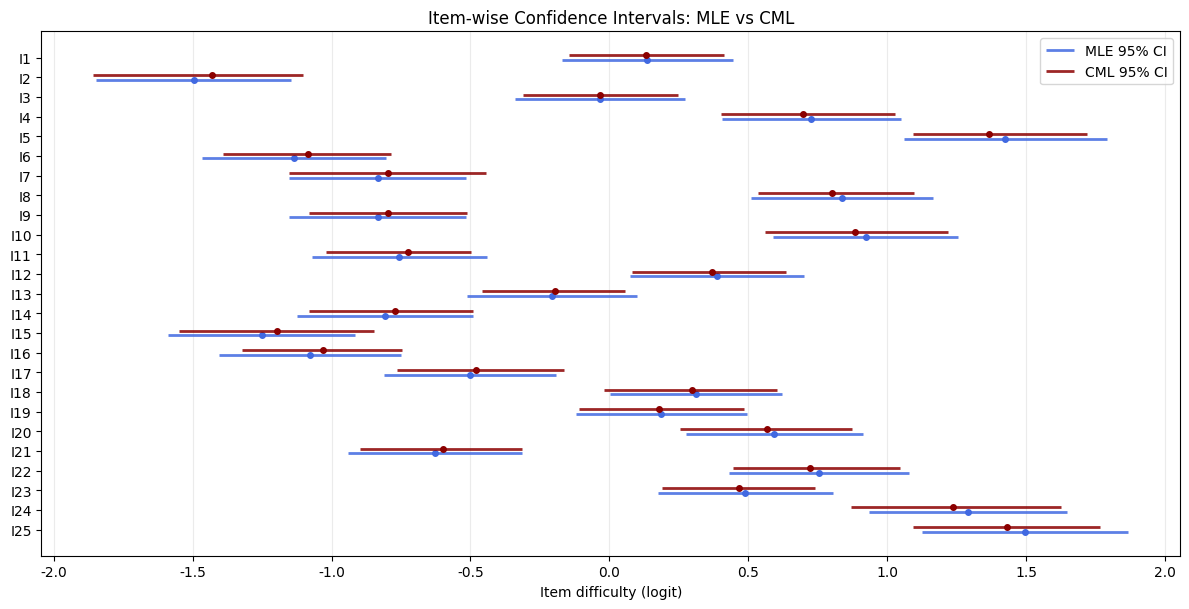

In [14]:
# Why beta_mle and beta_cml can be nearly identical + CI comparison by item
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Ensure required estimates/CIs exist ----
if 'beta_cml' not in globals() or 'se_beta_cml' not in globals():
    raise ValueError("Run the CML cell first so beta_cml and se_beta_cml are available.")

if 'b_lo' not in globals() or 'b_hi' not in globals():
    z = 1.96
    eta = theta_mle[:, None] - b_mle[None, :]
    P_hat = 1.0 / (1.0 + np.exp(-eta))
    W_hat = P_hat * (1.0 - P_hat)
    SE_b = 1.0 / np.sqrt(W_hat.sum(axis=0))
    b_lo = b_mle - z * SE_b
    b_hi = b_mle + z * SE_b

if 'beta_cml_lo' not in globals() or 'beta_cml_hi' not in globals():
    z = 1.96
    beta_cml_lo = beta_cml - z * se_beta_cml
    beta_cml_hi = beta_cml + z * se_beta_cml

# ---- Explanation ----
corr = np.corrcoef(b_mle, beta_cml)[0, 1]
rmse = np.sqrt(np.mean((b_mle - beta_cml) ** 2))
max_abs_diff = np.max(np.abs(b_mle - beta_cml))

print("Why are beta_mle and beta_cml almost the same?")
print("1) This is a pure Rasch (1PL) simulation generated from the same model form used for estimation.")
print("2) The sample size is fairly large (many persons), so JML and CML tend to converge to very similar item estimates.")
print("3) Identifiability constraints are aligned (item-location centered), reducing scale/shift differences.")
print("4) In well-behaved Rasch data, practical differences between JML and CML item locations are often small.")
print()
print(f"corr(beta_mle, beta_cml) = {corr:.6f}")
print(f"RMSE(beta_mle, beta_cml) = {rmse:.6f}")
print(f"max |beta_mle - beta_cml| = {max_abs_diff:.6f}")

# ---- CI comparison table ----
items = np.arange(1, len(b_mle) + 1)
width_mle = b_hi - b_lo
width_cml = beta_cml_hi - beta_cml_lo

# overlap length of two intervals
overlap = np.maximum(0.0, np.minimum(b_hi, beta_cml_hi) - np.maximum(b_lo, beta_cml_lo))

df_ci_comp = pd.DataFrame({
    'Item': items,
    'beta_mle': b_mle,
    'MLE_CI_low': b_lo,
    'MLE_CI_high': b_hi,
    'MLE_CI_width': width_mle,
    'beta_cml': beta_cml,
    'CML_CI_low': beta_cml_lo,
    'CML_CI_high': beta_cml_hi,
    'CML_CI_width': width_cml,
    'CI_overlap': overlap,
    'width_diff(CML-MLE)': width_cml - width_mle,
})

print("\nItem-level CI comparison (first 10 rows):")
print(df_ci_comp.head(10).to_string(index=False, float_format=lambda x: f"{x:8.4f}"))
print()
print(f"Mean CI width (MLE): {width_mle.mean():.4f}")
print(f"Mean CI width (CML): {width_cml.mean():.4f}")
print(f"Mean width diff (CML - MLE): {(width_cml - width_mle).mean():.4f}")

# ---- Visualization: paired CI intervals for each item ----
fig, ax = plt.subplots(figsize=(12, 6.2))
y = np.arange(len(items))

# MLE intervals
ax.hlines(y + 0.12, b_lo, b_hi, color='royalblue', lw=2.0, alpha=0.85, label='MLE 95% CI')
ax.plot(b_mle, y + 0.12, 'o', color='royalblue', ms=4)

# CML intervals
ax.hlines(y - 0.12, beta_cml_lo, beta_cml_hi, color='darkred', lw=2.0, alpha=0.85, label='CML 95% CI')
ax.plot(beta_cml, y - 0.12, 'o', color='darkred', ms=4)

ax.set_yticks(y)
ax.set_yticklabels([f'I{i}' for i in items])
ax.invert_yaxis()
ax.set_xlabel('Item difficulty (logit)')
ax.set_title('Item-wise Confidence Intervals: MLE vs CML')
ax.grid(axis='x', alpha=0.25)
ax.legend(loc='best')

plt.tight_layout()
plt.show()

## Why CML Can Be Better Than JML in Practice

There is no theorem saying CML is always numerically closer to truth than JML in every finite sample. However, in Rasch modeling there is strong theory favoring CML for item calibration:

- CML conditions on person raw scores (sufficient statistics for ability), removing nuisance person parameters from the item likelihood.
- This avoids the incidental-parameter issue that can affect JML when many person parameters are estimated jointly.
- Under standard Rasch assumptions, CML item estimation is generally more stable and principled for invariant item calibration.

Why your earlier results were similar:

- Your data were generated from the same Rasch model and had a reasonably informative sample.
- In such well-behaved settings, JML and CML can be very close.

When CML advantage becomes visible:

- Fewer items (short test)
- Smaller samples
- Skewed/irregular ability distributions
- More extreme response patterns (many all-correct/all-incorrect or near-extreme scores)

The simulation cell below intentionally creates such a hard regime and compares JML vs CML over repeated replications.

Hard regime summary across replications
JML mean RMSE: 0.2980  (SD 0.0880)
CML mean RMSE: 0.2301  (SD 0.0762)
JML mean bias: 0.0000
CML mean bias: 0.0000
CML better (lower RMSE) in 90.8% of replications


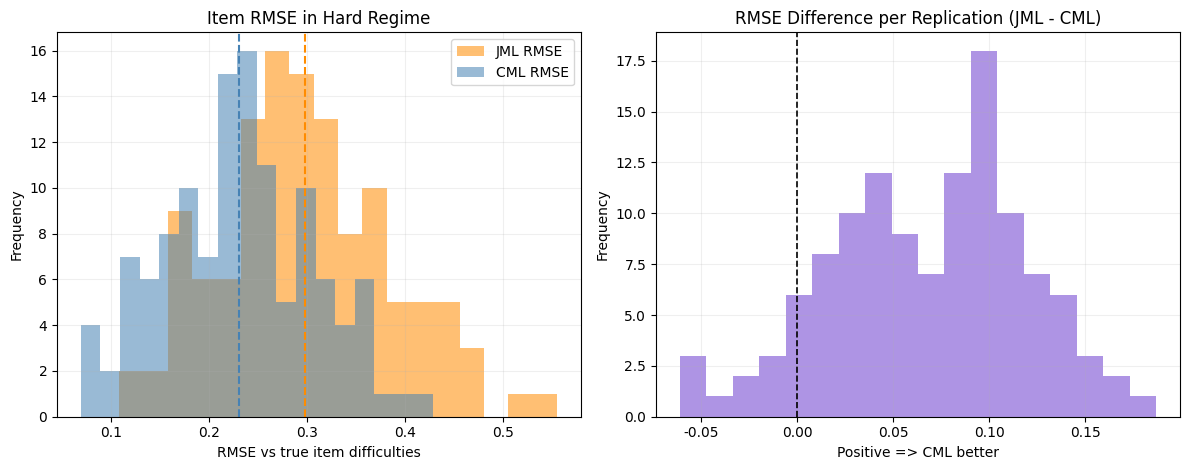

In [15]:
# Hard-regime simulation: show where CML and JML separate
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from girth import rasch_jml, rasch_conditional

rng = np.random.default_rng(5101)

# Hard regime settings
R = 120            # replications
J_hard = 80        # fewer persons
I_hard = 6         # few items -> JML incidental-parameter effects become more visible

rmse_jml = []
rmse_cml = []
bias_jml = []
bias_cml = []

for _ in range(R):
    # Skewed ability distribution with heavy tails + shift
    theta = rng.lognormal(mean=0.0, sigma=0.9, size=J_hard) - 1.6

    # Make test relatively hard to induce many low/extreme scores
    b_true_h = np.linspace(-0.2, 2.0, I_hard) + rng.normal(0, 0.18, I_hard)
    b_true_h -= b_true_h.mean()

    p = 1.0 / (1.0 + np.exp(-(theta[:, None] - b_true_h[None, :])))
    Y_h = (rng.uniform(size=(J_hard, I_hard)) < p)

    X_h = Y_h.T  # [items x persons] for girth

    fit_jml = rasch_jml(X_h)
    fit_cml = rasch_conditional(X_h)

    b_jml = np.asarray(fit_jml['Difficulty'], dtype=float)
    b_cml = np.asarray(fit_cml['Difficulty'], dtype=float)

    # Align to common location (mean-zero) for fair comparison to true parameters
    b_jml -= b_jml.mean()
    b_cml -= b_cml.mean()

    rmse_jml.append(np.sqrt(np.mean((b_jml - b_true_h) ** 2)))
    rmse_cml.append(np.sqrt(np.mean((b_cml - b_true_h) ** 2)))
    bias_jml.append(np.mean(b_jml - b_true_h))
    bias_cml.append(np.mean(b_cml - b_true_h))

rmse_jml = np.array(rmse_jml)
rmse_cml = np.array(rmse_cml)
bias_jml = np.array(bias_jml)
bias_cml = np.array(bias_cml)

print('Hard regime summary across replications')
print(f'JML mean RMSE: {rmse_jml.mean():.4f}  (SD {rmse_jml.std(ddof=1):.4f})')
print(f'CML mean RMSE: {rmse_cml.mean():.4f}  (SD {rmse_cml.std(ddof=1):.4f})')
print(f'JML mean bias: {bias_jml.mean():.4f}')
print(f'CML mean bias: {bias_cml.mean():.4f}')
print(f'CML better (lower RMSE) in {(rmse_cml < rmse_jml).mean()*100:.1f}% of replications')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

# RMSE comparison
axes[0].hist(rmse_jml, bins=18, alpha=0.55, color='darkorange', label='JML RMSE')
axes[0].hist(rmse_cml, bins=18, alpha=0.55, color='steelblue', label='CML RMSE')
axes[0].axvline(rmse_jml.mean(), color='darkorange', linestyle='--', lw=1.5)
axes[0].axvline(rmse_cml.mean(), color='steelblue', linestyle='--', lw=1.5)
axes[0].set_title('Item RMSE in Hard Regime')
axes[0].set_xlabel('RMSE vs true item difficulties')
axes[0].set_ylabel('Frequency')
axes[0].grid(alpha=0.2)
axes[0].legend(loc='best')

# Replication-level difference
delta = rmse_jml - rmse_cml
axes[1].hist(delta, bins=18, color='mediumpurple', alpha=0.75)
axes[1].axvline(0, color='black', linestyle='--', lw=1.2)
axes[1].set_title('RMSE Difference per Replication (JML - CML)')
axes[1].set_xlabel('Positive => CML better')
axes[1].set_ylabel('Frequency')
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

One-draw P(theta > max(b_raw)) = 5.0%


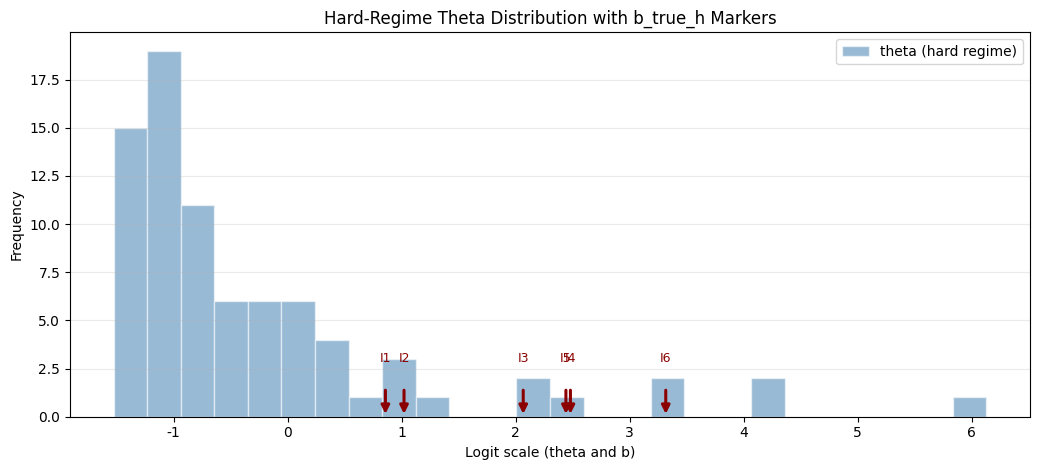

In [16]:
# Plot the theta distribution used in a hard-regime simulation
# and overlay b_true_h locations on the same axis
import numpy as np
import matplotlib.pyplot as plt

# Recreate one hard-regime draw for clear visualization
rng_vis = np.random.default_rng(5101)
J_hard_vis = 80
I_hard_vis = 6

theta_hard_vis = rng_vis.lognormal(mean=0.0, sigma=0.9, size=J_hard_vis) - 1.6
b_true_h_vis = np.linspace(0.9, 3.1, I_hard_vis) + rng_vis.normal(0, 0.18, I_hard_vis)
print(f'One-draw P(theta > max(b_raw)) = {(theta_hard_vis > b_true_h_vis.max()).mean()*100:.1f}%')

fig, ax = plt.subplots(figsize=(10.5, 4.8))
counts, bins, _ = ax.hist(
    theta_hard_vis,
    bins=26,
    color='steelblue',
    alpha=0.55,
    edgecolor='white',
    label='theta (hard regime)'
)

# Use short arrows to indicate item locations on the theta axis
ymax = counts.max() if len(counts) else 1.0
arrow_len = max(0.08 * ymax, 0.5)
for i, b in enumerate(b_true_h_vis, start=1):
    ax.annotate(
        '',
        xy=(b, 0.0),
        xytext=(b, arrow_len),
        arrowprops=dict(arrowstyle='-|>', color='darkred', lw=2.2, mutation_scale=12)
    )
    ax.text(b, arrow_len + 0.06 * ymax, f'I{i}', color='darkred', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Logit scale (theta and b)')
ax.set_ylabel('Frequency')
ax.set_title('Hard-Regime Theta Distribution with b_true_h Markers')
ax.grid(axis='y', alpha=0.25)
ax.legend(loc='best')

plt.tight_layout()
plt.show()

## MLE vs CML vs MAP vs Full Bayesian (MCMC): Do You Really Need MCMC?

### Quick Comparison

| Method | What it estimates | Strengths | Weaknesses | Typical use |
|---|---|---|---|---|
| **MLE / JML** | Maximize likelihood jointly for $\theta, b$ | Fast, simple, easy to implement (e.g., Stan `optimize()`) | Incidental-parameter bias risk in short tests/small samples; weak uncertainty quantification if Hessian is unstable | Baseline calibration, quick diagnostics |
| **CML** | Item parameters via conditional likelihood (eliminates $\theta$ nuisance parameters) | Rasch-consistent item calibration; strong invariance properties; often better finite-sample behavior for items | Not as general as Bayesian models; still need second-stage ability estimation | Rasch item calibration in operational settings |
| **MAP** | Posterior mode with priors | Stabilizes extreme estimates; usually much faster than MCMC | Not full posterior; prior-sensitive; uncertainty often Laplace-style approximation | Production scoring when regularization is needed |
| **Full Bayesian (MCMC)** | Full posterior of all parameters | Gold-standard uncertainty propagation; flexible hierarchy; handles missingness/latent structure naturally | Slow, tuning/convergence checks required, more modeling overhead | Final inferential analysis, complex models, high-stakes decisions |

### Should You Use Full Bayesian MCMC ?

**Short answer for your current notebook:** probably **no**, unless your goal is full uncertainty reporting or a richer hierarchical model.

### Reasons to choose CML than MCMC (for now)

1. **Your decision target appears to be point calibration + method comparison**, and CML/MAP already do that efficiently.
2. **You already observe near-identical point estimates in regular regimes**, so MCMC would mostly add compute cost, not practical gain.
3. **MCMC cost is high**: multiple chains, warmup, diagnostics ($\hat{R}$, ESS, divergences), and posterior checks.
4. **For routine Rasch calibration**, CML is usually the principled frequentist default, and MAP is a robust fallback for extreme-score stabilization.
5. **Your current questions are methodological/operational**, not posterior-probability questions (e.g., "What is $P(b_i > b_j\mid Y)$?").

### When MCMC Is Worth It

Use full Bayesian MCMC if at least one of these is true:

- You need **full posterior intervals** and probability statements for decisions.
- You need **hierarchical priors** (multi-group, test forms, linking/equating, random item effects).
- You have **small samples/sparse data** where prior pooling materially improves stability.
- You need to propagate uncertainty to downstream decisions in a formally coherent way.

### Practical Recommendation

For this project, use a **two-track strategy**:

- **Default track**: CML (items) + MLE/WLE/EAP (abilities) or MAP for stable operational reporting.
- **Escalation track**: run Stan MCMC only for final confirmatory analyses or when model complexity justifies the extra cost.

---
## Hard-regime setup for CML, MAP, MCMC
- 고난도 조건 설정

Comparison dataset shape: (80, 6)
Observed proportion correct: 0.150
P(theta > max(b_raw)): 5.0%


23:26:42 - cmdstanpy - INFO - compiling stan file C:\Users\yongd\Downloads\KOS-5101\irt\rasch_1pl_map_compare.stan to exe file C:\Users\yongd\Downloads\KOS-5101\irt\rasch_1pl_map_compare.exe
23:26:52 - cmdstanpy - INFO - compiled model executable: C:\Users\yongd\Downloads\KOS-5101\irt\rasch_1pl_map_compare.exe
23:26:52 - cmdstanpy - INFO - compiling stan file C:\Users\yongd\Downloads\KOS-5101\irt\rasch_1pl_mcmc_compare.stan to exe file C:\Users\yongd\Downloads\KOS-5101\irt\rasch_1pl_mcmc_compare.exe
23:27:03 - cmdstanpy - INFO - compiled model executable: C:\Users\yongd\Downloads\KOS-5101\irt\rasch_1pl_mcmc_compare.exe
23:27:03 - cmdstanpy - INFO - Chain [1] start processing
23:27:03 - cmdstanpy - INFO - Chain [1] done processing
23:27:03 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

23:27:05 - cmdstanpy - INFO - CmdStan done processing.


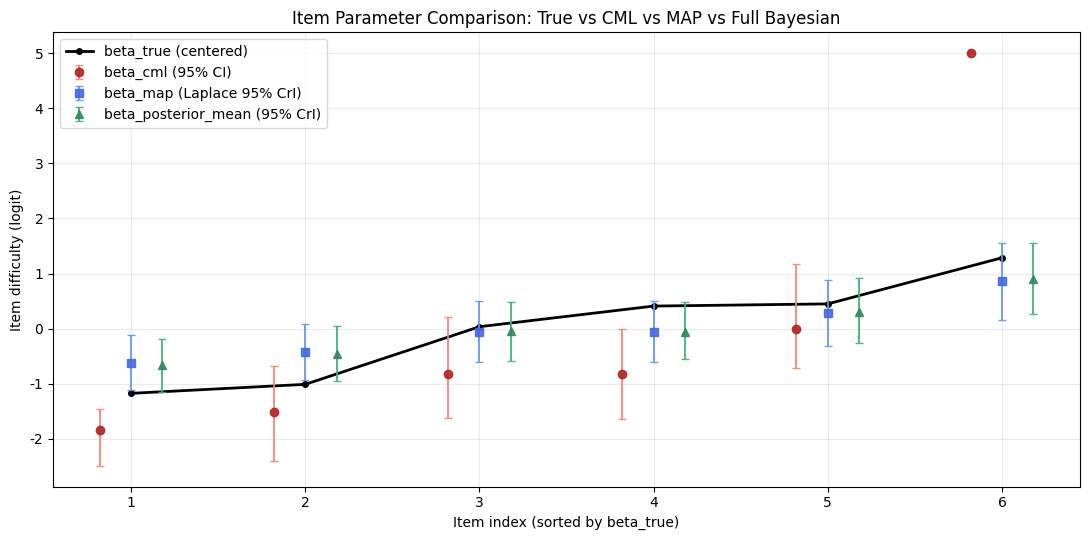

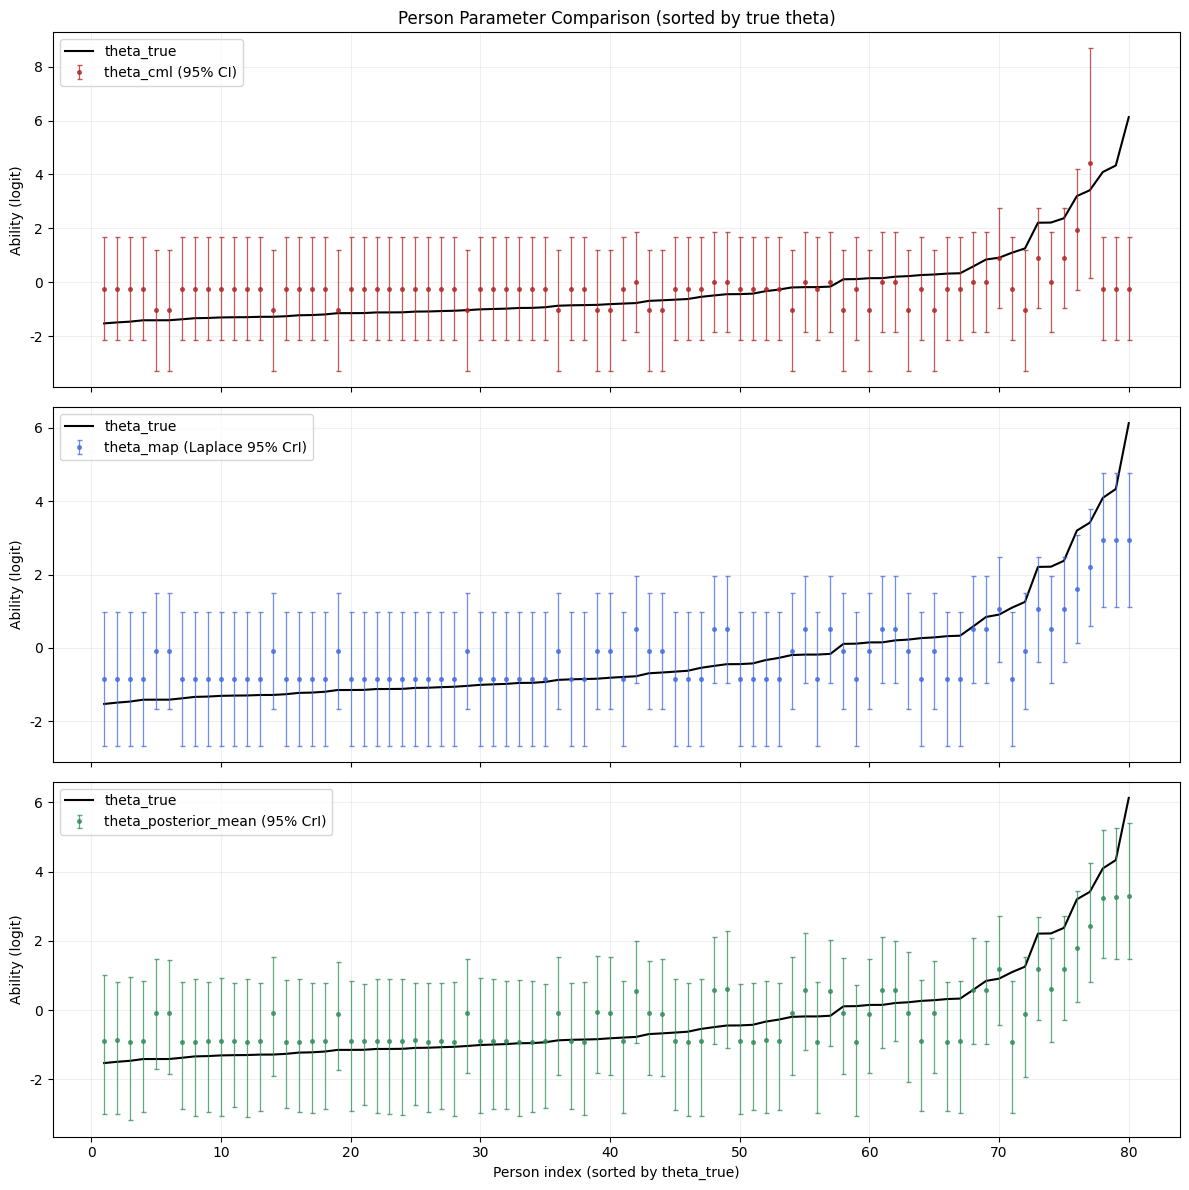

Done: CML, MAP, and Full Bayesian MCMC comparison completed on Cell 26 hard-regime setup.


In [17]:
# Comparative estimation on hard-regime setup from Cell 26: CML vs MAP vs Full Bayesian (MCMC)
import numpy as np
import matplotlib.pyplot as plt
import cmdstanpy
from girth import rasch_conditional, ability_mle

# ---------- 0) Use Cell 26 parameters and generate responses ----------
if 'theta_hard_vis' not in globals() or 'b_true_h_vis' not in globals():
    raise ValueError('Run Cell 26 first so theta_hard_vis and b_true_h_vis are available.')

theta_true_cmp = np.asarray(theta_hard_vis, dtype=float)
beta_true_raw = np.asarray(b_true_h_vis, dtype=float)
J_cmp = theta_true_cmp.size
I_cmp = beta_true_raw.size

rng_cmp = np.random.default_rng(2601)
p_cmp = 1.0 / (1.0 + np.exp(-(theta_true_cmp[:, None] - beta_true_raw[None, :])))
Y_cmp = (rng_cmp.uniform(size=(J_cmp, I_cmp)) < p_cmp).astype(int)

print(f'Comparison dataset shape: {Y_cmp.shape}')
print(f'Observed proportion correct: {Y_cmp.mean():.3f}')
print(f'P(theta > max(b_raw)): {(theta_true_cmp > beta_true_raw.max()).mean()*100:.1f}%')

# ---------- 1) CML ----------
X_cmp = Y_cmp.T.astype(bool)  # girth expects [items x persons]
fit_cml_cmp = rasch_conditional(X_cmp)
beta_cml_cmp = np.asarray(fit_cml_cmp['Difficulty'] if isinstance(fit_cml_cmp, dict) else fit_cml_cmp, dtype=float)
beta_cml_cmp -= beta_cml_cmp.mean()

theta_cml_cmp = np.asarray(ability_mle(X_cmp, beta_cml_cmp, np.ones_like(beta_cml_cmp)), dtype=float)
if np.isnan(theta_cml_cmp).any():
    theta_cml_cmp = np.where(np.isnan(theta_cml_cmp), np.nanmean(theta_cml_cmp), theta_cml_cmp)

# CML item CIs by bootstrap
B = 200
beta_cml_boot = np.zeros((B, I_cmp), dtype=float)
for b in range(B):
    idx = rng_cmp.integers(0, J_cmp, J_cmp)
    Xb = Y_cmp[idx, :].T.astype(bool)
    fit_b = rasch_conditional(Xb)
    bb = np.asarray(fit_b['Difficulty'] if isinstance(fit_b, dict) else fit_b, dtype=float)
    beta_cml_boot[b, :] = bb - bb.mean()

beta_cml_lo = np.percentile(beta_cml_boot, 2.5, axis=0)
beta_cml_hi = np.percentile(beta_cml_boot, 97.5, axis=0)

eta_cml = theta_cml_cmp[:, None] - beta_cml_cmp[None, :]
W_cml = (1.0 / (1.0 + np.exp(-eta_cml))) * (1.0 - 1.0 / (1.0 + np.exp(-eta_cml)))
se_theta_cml = 1.0 / np.sqrt(np.clip(W_cml.sum(axis=1), 1e-10, None))
theta_cml_lo = theta_cml_cmp - 1.96 * se_theta_cml
theta_cml_hi = theta_cml_cmp + 1.96 * se_theta_cml

# ---------- 2) Stan MAP + Full Bayesian MCMC ----------
jj = np.repeat(np.arange(1, J_cmp + 1), I_cmp).tolist()
ii = np.tile(np.arange(1, I_cmp + 1), J_cmp).tolist()
y_long = Y_cmp.reshape(-1).astype(int).tolist()

stan_data_cmp = {
    'J': J_cmp,
    'I': I_cmp,
    'N': J_cmp * I_cmp,
    'jj': jj,
    'ii': ii,
    'y': y_long,
    'sigma_prior': 1.5,
}

stan_code_map = """
data {
  int<lower=1> J;
  int<lower=1> I;
  int<lower=0> N;
  array[N] int<lower=1, upper=J> jj;
  array[N] int<lower=1, upper=I> ii;
  array[N] int<lower=0, upper=1> y;
  real<lower=0> sigma_prior;
}
parameters {
  vector[J] theta;
  vector[I-1] b_free;
}
transformed parameters {
  vector[I] b;
  b[1:I-1] = b_free;
  b[I] = -sum(b_free);
}
model {
  theta ~ normal(0, sigma_prior);
  b_free ~ normal(0, sigma_prior);
  for (n in 1:N) y[n] ~ bernoulli_logit(theta[jj[n]] - b[ii[n]]);
}
"""

# Same model specification, but inferred with HMC sampling for full posterior
stan_code_mcmc = stan_code_map

map_file = 'rasch_1pl_map_compare.stan'
mcmc_file = 'rasch_1pl_mcmc_compare.stan'
with open(map_file, 'w', encoding='utf-8') as f:
    f.write(stan_code_map)
with open(mcmc_file, 'w', encoding='utf-8') as f:
    f.write(stan_code_mcmc)

model_map = cmdstanpy.CmdStanModel(stan_file=map_file)
model_mcmc = cmdstanpy.CmdStanModel(stan_file=mcmc_file)

fit_map_cmp = model_map.optimize(data=stan_data_cmp)
beta_map_cmp = fit_map_cmp.stan_variable('b')
theta_map_cmp = fit_map_cmp.stan_variable('theta')

# MAP credible intervals via quadratic (Laplace) approximation
sigma_prior = stan_data_cmp['sigma_prior']
eta_map = theta_map_cmp[:, None] - beta_map_cmp[None, :]
P_map = 1.0 / (1.0 + np.exp(-eta_map))
W_map = P_map * (1.0 - P_map)

prec_theta_map = W_map.sum(axis=1) + 1.0 / (sigma_prior ** 2)
prec_beta_map = W_map.sum(axis=0) + 1.0 / (sigma_prior ** 2)
se_theta_map = 1.0 / np.sqrt(np.clip(prec_theta_map, 1e-10, None))
se_beta_map = 1.0 / np.sqrt(np.clip(prec_beta_map, 1e-10, None))

theta_map_lo = theta_map_cmp - 1.96 * se_theta_map
theta_map_hi = theta_map_cmp + 1.96 * se_theta_map
beta_map_lo = beta_map_cmp - 1.96 * se_beta_map
beta_map_hi = beta_map_cmp + 1.96 * se_beta_map

fit_mcmc_cmp = model_mcmc.sample(
    data=stan_data_cmp,
    chains=2,
    parallel_chains=2,
    iter_warmup=500,
    iter_sampling=800,
    seed=5101,
    show_progress=True,
    refresh=100,
    adapt_delta=0.9,
    max_treedepth=12,
    inits=0,
    output_dir='.'
)

beta_draws = fit_mcmc_cmp.stan_variable('b')        # [draws, I]
theta_draws = fit_mcmc_cmp.stan_variable('theta')    # [draws, J]

beta_post_mean = beta_draws.mean(axis=0)
beta_post_lo = np.percentile(beta_draws, 2.5, axis=0)
beta_post_hi = np.percentile(beta_draws, 97.5, axis=0)

theta_post_mean = theta_draws.mean(axis=0)
theta_post_lo = np.percentile(theta_draws, 2.5, axis=0)
theta_post_hi = np.percentile(theta_draws, 97.5, axis=0)

# ---------- 3) Identification alignment for fair plotting ----------
# Items: compare on centered scale (Stan uses sum-to-zero location for b)
beta_true_ctr = beta_true_raw - beta_true_raw.mean()

# Persons: align each method to true-theta mean by additive shift
def _align_to_true_mean(est, lo, hi, theta_true):
    shift = theta_true.mean() - est.mean()
    return est + shift, lo + shift, hi + shift

theta_cml_al, theta_cml_lo_al, theta_cml_hi_al = _align_to_true_mean(theta_cml_cmp, theta_cml_lo, theta_cml_hi, theta_true_cmp)
theta_map_al, theta_map_lo_al, theta_map_hi_al = _align_to_true_mean(theta_map_cmp, theta_map_lo, theta_map_hi, theta_true_cmp)
theta_post_al, theta_post_lo_al, theta_post_hi_al = _align_to_true_mean(theta_post_mean, theta_post_lo, theta_post_hi, theta_true_cmp)

# ---------- 4) Item comparison figure ----------
order_i = np.argsort(beta_true_ctr)
x_i = np.arange(1, I_cmp + 1)
xt_i = x_i

true_i = beta_true_ctr[order_i]
cml_i = beta_cml_cmp[order_i]
map_i = beta_map_cmp[order_i]
mcmc_i = beta_post_mean[order_i]

cml_lo_i, cml_hi_i = beta_cml_lo[order_i], beta_cml_hi[order_i]
map_lo_i, map_hi_i = beta_map_lo[order_i], beta_map_hi[order_i]
mcmc_lo_i, mcmc_hi_i = beta_post_lo[order_i], beta_post_hi[order_i]

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(xt_i, true_i, color='black', lw=2.0, marker='o', ms=4, label='beta_true (centered)')

offset = 0.18
ax.errorbar(xt_i - offset, cml_i, yerr=np.vstack([cml_i - cml_lo_i, cml_hi_i - cml_i]), fmt='o',
            color='firebrick', ecolor='salmon', elinewidth=1.4, capsize=3, alpha=0.9, label='beta_cml (95% CI)')
ax.errorbar(xt_i, map_i, yerr=np.vstack([map_i - map_lo_i, map_hi_i - map_i]), fmt='s',
            color='royalblue', ecolor='cornflowerblue', elinewidth=1.4, capsize=3, alpha=0.9, label='beta_map (Laplace 95% CrI)')
ax.errorbar(xt_i + offset, mcmc_i, yerr=np.vstack([mcmc_i - mcmc_lo_i, mcmc_hi_i - mcmc_i]), fmt='^',
            color='seagreen', ecolor='mediumseagreen', elinewidth=1.4, capsize=3, alpha=0.9, label='beta_posterior_mean (95% CrI)')

ax.set_xlabel('Item index (sorted by beta_true)')
ax.set_ylabel('Item difficulty (logit)')
ax.set_title('Item Parameter Comparison: True vs CML vs MAP vs Full Bayesian')
ax.grid(alpha=0.25)
ax.legend(loc='best')
plt.tight_layout()
plt.show()

# ---------- 5) Person comparison figure ----------
order_p = np.argsort(theta_true_cmp)
x_p = np.arange(1, J_cmp + 1)
theta_true_s = theta_true_cmp[order_p]

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

def _plot_person_panel(ax, est, lo, hi, color, title):
    est_s = est[order_p]
    lo_s = lo[order_p]
    hi_s = hi[order_p]
    ax.plot(x_p, theta_true_s, color='black', lw=1.5, label='theta_true')
    ax.errorbar(
        x_p, est_s,
        yerr=np.vstack([est_s - lo_s, hi_s - est_s]),
        fmt='o', ms=2.6, color=color,
        ecolor=color, elinewidth=0.9, capsize=1.8, alpha=0.75,
        label=title
    )
    ax.set_ylabel('Ability (logit)')
    ax.grid(alpha=0.2)
    ax.legend(loc='best')

_plot_person_panel(axes[0], theta_cml_al, theta_cml_lo_al, theta_cml_hi_al, 'firebrick', 'theta_cml (95% CI)')
_plot_person_panel(axes[1], theta_map_al, theta_map_lo_al, theta_map_hi_al, 'royalblue', 'theta_map (Laplace 95% CrI)')
_plot_person_panel(axes[2], theta_post_al, theta_post_lo_al, theta_post_hi_al, 'seagreen', 'theta_posterior_mean (95% CrI)')

axes[0].set_title('Person Parameter Comparison (sorted by true theta)')
axes[2].set_xlabel('Person index (sorted by theta_true)')
plt.tight_layout()
plt.show()

print('Done: CML, MAP, and Full Bayesian MCMC comparison completed on Cell 26 hard-regime setup.')

## Interpretation of the Comparison Results (My Analysis)

Your three observations are statistically coherent for this hard-regime setup.

### 1) Why CML appears to "fail" for one item difficulty

What you see (one very large `beta_cml`) is most likely a **boundary / quasi-separation phenomenon**, not a coding bug.

- In this dataset, the test is intentionally hard (`P(theta > max(b_raw))` is small), so some items can be almost never solved.
- For Rasch CML, if an item behaves nearly extreme (very low or very high pass rate), the conditional likelihood can push its difficulty toward very large magnitude.
- Numerically, software returns a finite but extreme value (instead of literal $+\infty$), which looks like a "failed" estimate.

So interpretation: CML is signaling that this item is weakly identified under this sample-targeting combination.

### 2) Why MCMC intervals can be narrower than CML and MAP intervals

This is plausible here for two main reasons.

- **Prior shrinkage**: MAP/MCMC use priors (`Normal(0, 1.5)` here), which regularize extreme values. MCMC posterior intervals are conditional on that prior and therefore can contract relative to purely likelihood-driven uncertainty.
- **Different uncertainty targets**: your CML item intervals are bootstrap-based and can be wider in small, hard, sparse settings because they include stronger sampling variability from repeated resampling.

Also, MAP intervals here come from a **Laplace (quadratic) approximation**, while MCMC intervals come from sampled posterior quantiles; either can be wider depending on local curvature and nonlinearity.

### 3) Why one person CI is very large

A very large CI for a person usually means **low Fisher information** for that respondent.

In Rasch form, person information is
$$
\mathcal{I}(\theta_j)=\sum_i P_{ji}(1-P_{ji}).
$$
If a person has an extreme response pattern (near all 0 or all 1), then many $P_{ji}$ are near 0 or 1, so $P_{ji}(1-P_{ji})\approx 0$, and
$$
\mathrm{SE}(\theta_j) \propto \frac{1}{\sqrt{\mathcal{I}(\theta_j)}}
$$
becomes large. In a hard test, low-ability examinees are especially prone to this.

### Practical implication

- The pattern you observed is **diagnostically meaningful**, not accidental.
- It indicates **mismatch between item targeting and ability distribution** plus expected behavior of each estimator under extreme data.
- If needed, stabilization options are: stronger priors, WLE/EAP for persons, remove/flag extreme items, or redesign item targeting so item difficulties better cover the ability range.

---
## Larget NJ, NI, and well-balenced data
NJ = 200

NI = 25

Dataset shape: (200, 25)
Observed proportion correct: 0.476


23:27:10 - cmdstanpy - INFO - compiling stan file C:\Users\yongd\Downloads\KOS-5101\irt\rasch_1pl_map_mcmc_std.stan to exe file C:\Users\yongd\Downloads\KOS-5101\irt\rasch_1pl_map_mcmc_std.exe
23:27:21 - cmdstanpy - INFO - compiled model executable: C:\Users\yongd\Downloads\KOS-5101\irt\rasch_1pl_map_mcmc_std.exe
23:27:21 - cmdstanpy - INFO - Chain [1] start processing
23:27:21 - cmdstanpy - INFO - Chain [1] done processing
23:27:21 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

23:27:49 - cmdstanpy - INFO - CmdStan done processing.


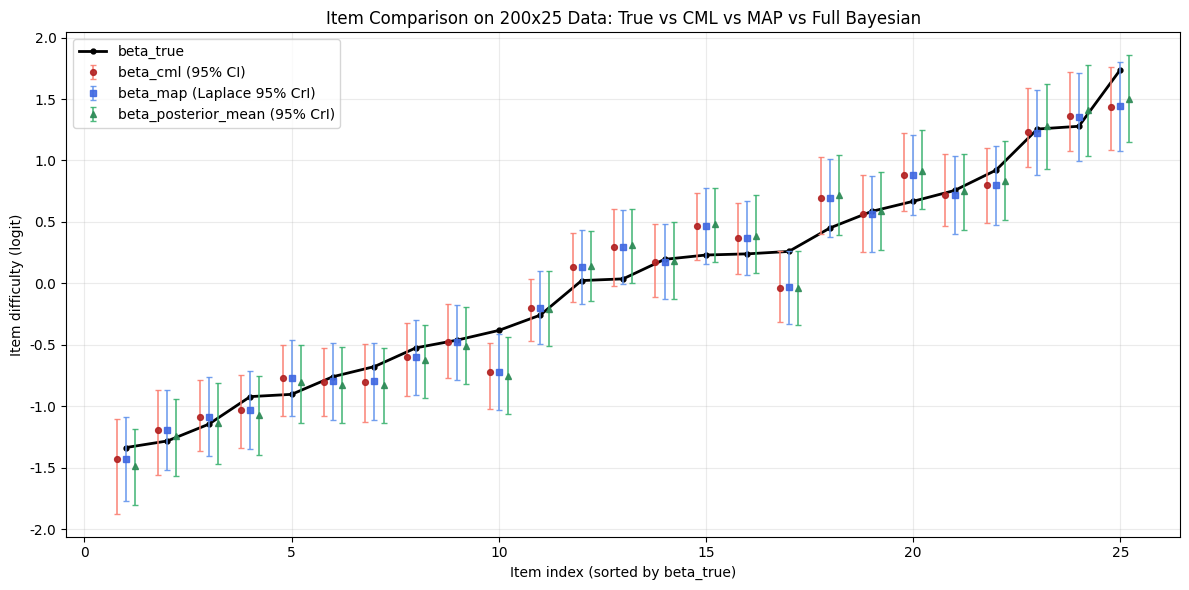

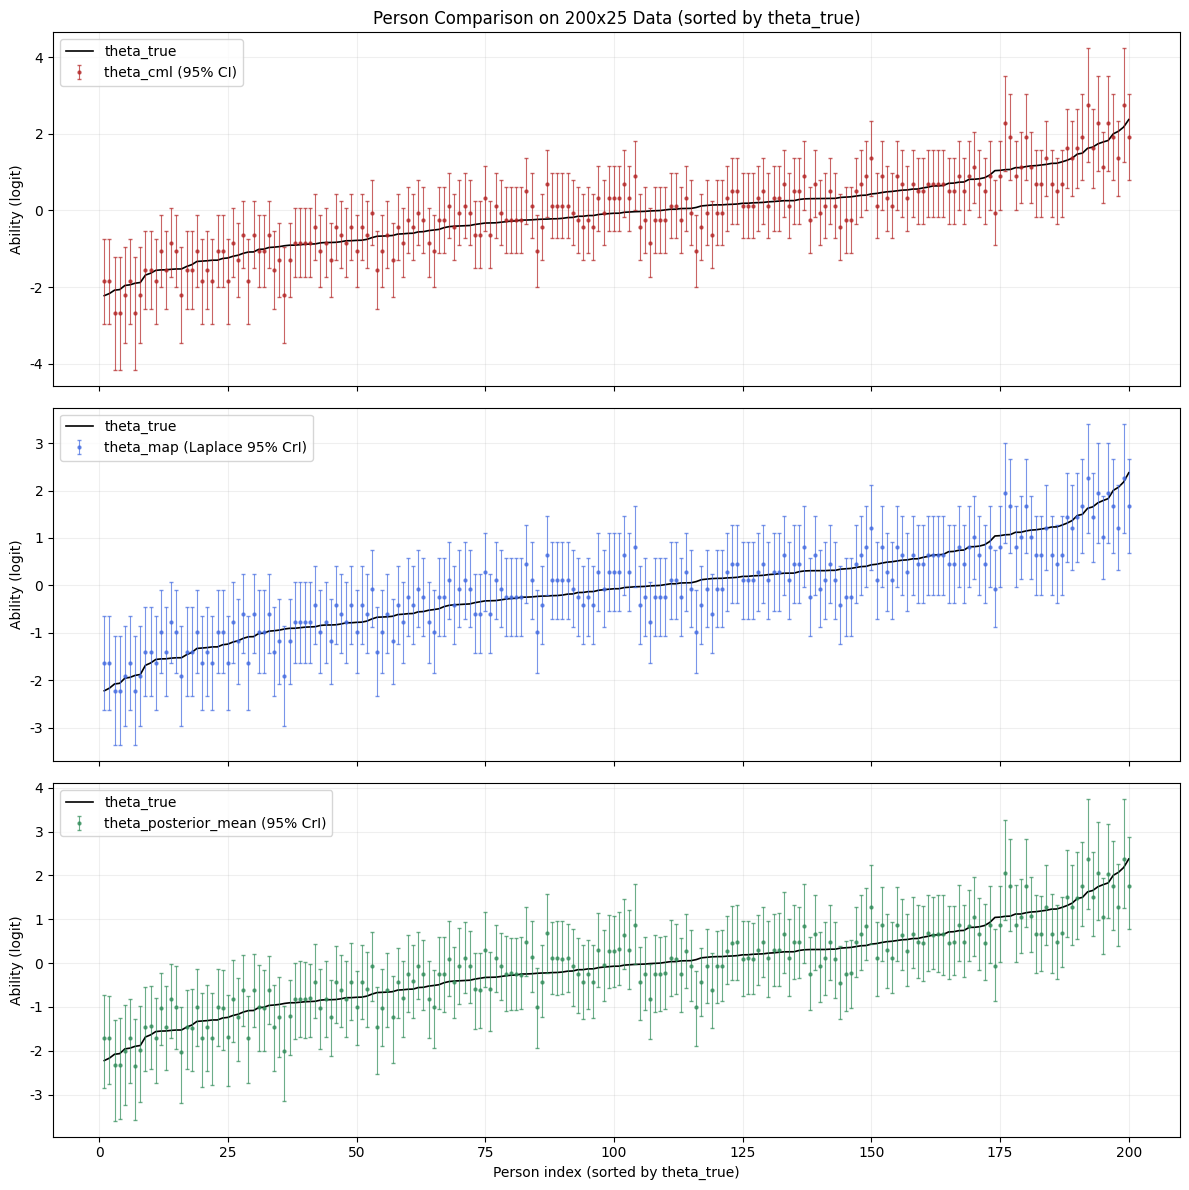

Done: CML, MAP, and Full Bayesian MCMC computed on the original 200x25 dataset.


In [18]:
# Comparison on original dataset (Cell 20 context): CML vs MAP vs Full Bayesian MCMC
import numpy as np
import matplotlib.pyplot as plt
import cmdstanpy
from girth import rasch_conditional, ability_mle

# ---------- 0) Use original generated dataset ----------
if 'Y' not in globals() or 'theta_true' not in globals() or 'b_true' not in globals():
    raise ValueError('Run the data-generation cell first so Y, theta_true, and b_true are available.')

Y_std = np.asarray(Y, dtype=int)
theta_true_std = np.asarray(theta_true, dtype=float)
beta_true_std = np.asarray(b_true, dtype=float)
J_std, I_std = Y_std.shape

print(f'Dataset shape: {Y_std.shape}')
print(f'Observed proportion correct: {Y_std.mean():.3f}')

# ---------- 1) CML ----------
X_std = Y_std.T.astype(bool)  # [items x persons] for girth
fit_cml_std = rasch_conditional(X_std)
beta_cml_std = np.asarray(fit_cml_std['Difficulty'] if isinstance(fit_cml_std, dict) else fit_cml_std, dtype=float)
beta_cml_std -= beta_cml_std.mean()

theta_cml_std = np.asarray(ability_mle(X_std, beta_cml_std, np.ones_like(beta_cml_std)), dtype=float)
if np.isnan(theta_cml_std).any():
    theta_cml_std = np.where(np.isnan(theta_cml_std), np.nanmean(theta_cml_std), theta_cml_std)

# CML item CIs: bootstrap
rng_std = np.random.default_rng(5101)
B_std = 150
beta_cml_boot_std = np.zeros((B_std, I_std), dtype=float)
for b in range(B_std):
    idx = rng_std.integers(0, J_std, J_std)
    Xb = Y_std[idx, :].T.astype(bool)
    fit_b = rasch_conditional(Xb)
    bb = np.asarray(fit_b['Difficulty'] if isinstance(fit_b, dict) else fit_b, dtype=float)
    beta_cml_boot_std[b, :] = bb - bb.mean()

beta_cml_lo_std = np.percentile(beta_cml_boot_std, 2.5, axis=0)
beta_cml_hi_std = np.percentile(beta_cml_boot_std, 97.5, axis=0)

# CML person CIs: information approximation
eta_cml_std = theta_cml_std[:, None] - beta_cml_std[None, :]
P_cml_std = 1.0 / (1.0 + np.exp(-eta_cml_std))
W_cml_std = P_cml_std * (1.0 - P_cml_std)
se_theta_cml_std = 1.0 / np.sqrt(np.clip(W_cml_std.sum(axis=1), 1e-10, None))
theta_cml_lo_std = theta_cml_std - 1.96 * se_theta_cml_std
theta_cml_hi_std = theta_cml_std + 1.96 * se_theta_cml_std

# ---------- 2) Stan MAP and Full Bayesian MCMC ----------
jj_std = np.repeat(np.arange(1, J_std + 1), I_std).tolist()
ii_std = np.tile(np.arange(1, I_std + 1), J_std).tolist()
y_std_long = Y_std.reshape(-1).astype(int).tolist()

stan_data_std = {
    'J': J_std,
    'I': I_std,
    'N': J_std * I_std,
    'jj': jj_std,
    'ii': ii_std,
    'y': y_std_long,
    'sigma_prior': 1.5,
}

stan_code_std = """
data {
  int<lower=1> J;
  int<lower=1> I;
  int<lower=0> N;
  array[N] int<lower=1, upper=J> jj;
  array[N] int<lower=1, upper=I> ii;
  array[N] int<lower=0, upper=1> y;
  real<lower=0> sigma_prior;
}
parameters {
  vector[J] theta;
  vector[I-1] b_free;
}
transformed parameters {
  vector[I] b;
  b[1:I-1] = b_free;
  b[I] = -sum(b_free);
}
model {
  theta ~ normal(0, sigma_prior);
  b_free ~ normal(0, sigma_prior);
  for (n in 1:N) y[n] ~ bernoulli_logit(theta[jj[n]] - b[ii[n]]);
}
"""

stan_file_std = 'rasch_1pl_map_mcmc_std.stan'
with open(stan_file_std, 'w', encoding='utf-8') as f:
    f.write(stan_code_std)

model_std = cmdstanpy.CmdStanModel(stan_file=stan_file_std)

# MAP
fit_map_std = model_std.optimize(data=stan_data_std)
beta_map_std = fit_map_std.stan_variable('b')
theta_map_std = fit_map_std.stan_variable('theta')

# MAP CrI via quadratic (Laplace) approximation
sigma_prior_std = stan_data_std['sigma_prior']
eta_map_std = theta_map_std[:, None] - beta_map_std[None, :]
P_map_std = 1.0 / (1.0 + np.exp(-eta_map_std))
W_map_std = P_map_std * (1.0 - P_map_std)

prec_theta_map_std = W_map_std.sum(axis=1) + 1.0 / (sigma_prior_std ** 2)
prec_beta_map_std = W_map_std.sum(axis=0) + 1.0 / (sigma_prior_std ** 2)
se_theta_map_std = 1.0 / np.sqrt(np.clip(prec_theta_map_std, 1e-10, None))
se_beta_map_std = 1.0 / np.sqrt(np.clip(prec_beta_map_std, 1e-10, None))

theta_map_lo_std = theta_map_std - 1.96 * se_theta_map_std
theta_map_hi_std = theta_map_std + 1.96 * se_theta_map_std
beta_map_lo_std = beta_map_std - 1.96 * se_beta_map_std
beta_map_hi_std = beta_map_std + 1.96 * se_beta_map_std

# Full Bayesian MCMC
fit_mcmc_std = model_std.sample(
    data=stan_data_std,
    chains=2,
    parallel_chains=2,
    iter_warmup=500,
    iter_sampling=700,
    seed=5101,
    adapt_delta=0.9,
    max_treedepth=12,
    inits=0,
    show_progress=True,
    refresh=100,
    output_dir='.'
)

beta_draws_std = fit_mcmc_std.stan_variable('b')
theta_draws_std = fit_mcmc_std.stan_variable('theta')

beta_post_mean_std = beta_draws_std.mean(axis=0)
beta_post_lo_std = np.percentile(beta_draws_std, 2.5, axis=0)
beta_post_hi_std = np.percentile(beta_draws_std, 97.5, axis=0)

theta_post_mean_std = theta_draws_std.mean(axis=0)
theta_post_lo_std = np.percentile(theta_draws_std, 2.5, axis=0)
theta_post_hi_std = np.percentile(theta_draws_std, 97.5, axis=0)

# ---------- 3) Align person locations to true-theta mean for fair visual comparison ----------
def _align_to_true_mean(est, lo, hi, theta_true_vec):
    shift = theta_true_vec.mean() - est.mean()
    return est + shift, lo + shift, hi + shift

theta_cml_al_std, theta_cml_lo_al_std, theta_cml_hi_al_std = _align_to_true_mean(
    theta_cml_std, theta_cml_lo_std, theta_cml_hi_std, theta_true_std
)
theta_map_al_std, theta_map_lo_al_std, theta_map_hi_al_std = _align_to_true_mean(
    theta_map_std, theta_map_lo_std, theta_map_hi_std, theta_true_std
)
theta_post_al_std, theta_post_lo_al_std, theta_post_hi_al_std = _align_to_true_mean(
    theta_post_mean_std, theta_post_lo_std, theta_post_hi_std, theta_true_std
)

# ---------- 4) Item figure: beta_true, beta_cml, beta_map, beta_posterior_mean + intervals ----------
ord_i_std = np.argsort(beta_true_std)
x_i_std = np.arange(1, I_std + 1)
off = 0.22

true_i_std = beta_true_std[ord_i_std]
cml_i_std = beta_cml_std[ord_i_std]
map_i_std = beta_map_std[ord_i_std]
mcmc_i_std = beta_post_mean_std[ord_i_std]

cml_lo_i_std, cml_hi_i_std = beta_cml_lo_std[ord_i_std], beta_cml_hi_std[ord_i_std]
map_lo_i_std, map_hi_i_std = beta_map_lo_std[ord_i_std], beta_map_hi_std[ord_i_std]
mcmc_lo_i_std, mcmc_hi_i_std = beta_post_lo_std[ord_i_std], beta_post_hi_std[ord_i_std]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(x_i_std, true_i_std, color='black', lw=2.0, marker='o', ms=3.5, label='beta_true')
ax.errorbar(
    x_i_std - off, cml_i_std,
    yerr=np.vstack([cml_i_std - cml_lo_i_std, cml_hi_i_std - cml_i_std]),
    fmt='o', ms=4.2, color='firebrick', ecolor='salmon', elinewidth=1.2, capsize=2.5, alpha=0.9,
    label='beta_cml (95% CI)'
)
ax.errorbar(
    x_i_std, map_i_std,
    yerr=np.vstack([map_i_std - map_lo_i_std, map_hi_i_std - map_i_std]),
    fmt='s', ms=4.2, color='royalblue', ecolor='cornflowerblue', elinewidth=1.2, capsize=2.5, alpha=0.9,
    label='beta_map (Laplace 95% CrI)'
)
ax.errorbar(
    x_i_std + off, mcmc_i_std,
    yerr=np.vstack([mcmc_i_std - mcmc_lo_i_std, mcmc_hi_i_std - mcmc_i_std]),
    fmt='^', ms=4.5, color='seagreen', ecolor='mediumseagreen', elinewidth=1.2, capsize=2.5, alpha=0.9,
    label='beta_posterior_mean (95% CrI)'
)
ax.set_xlabel('Item index (sorted by beta_true)')
ax.set_ylabel('Item difficulty (logit)')
ax.set_title('Item Comparison on 200x25 Data: True vs CML vs MAP vs Full Bayesian')
ax.grid(alpha=0.25)
ax.legend(loc='best')
plt.tight_layout()
plt.show()

# ---------- 5) Person figures ----------
ord_p_std = np.argsort(theta_true_std)
x_p_std = np.arange(1, J_std + 1)
theta_true_s_std = theta_true_std[ord_p_std]

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

def _plot_person(ax, est, lo, hi, color, label):
    est_s = est[ord_p_std]
    lo_s = lo[ord_p_std]
    hi_s = hi[ord_p_std]
    ax.plot(x_p_std, theta_true_s_std, color='black', lw=1.2, label='theta_true')
    ax.errorbar(
        x_p_std, est_s,
        yerr=np.vstack([est_s - lo_s, hi_s - est_s]),
        fmt='o', ms=2.1, color=color, ecolor=color, elinewidth=0.8, capsize=1.6, alpha=0.7,
        label=label
    )
    ax.set_ylabel('Ability (logit)')
    ax.grid(alpha=0.2)
    ax.legend(loc='best')

_plot_person(axes[0], theta_cml_al_std, theta_cml_lo_al_std, theta_cml_hi_al_std, 'firebrick', 'theta_cml (95% CI)')
_plot_person(axes[1], theta_map_al_std, theta_map_lo_al_std, theta_map_hi_al_std, 'royalblue', 'theta_map (Laplace 95% CrI)')
_plot_person(axes[2], theta_post_al_std, theta_post_lo_al_std, theta_post_hi_al_std, 'seagreen', 'theta_posterior_mean (95% CrI)')

axes[0].set_title('Person Comparison on 200x25 Data (sorted by theta_true)')
axes[2].set_xlabel('Person index (sorted by theta_true)')
plt.tight_layout()
plt.show()

print('Done: CML, MAP, and Full Bayesian MCMC computed on the original 200x25 dataset.')